# TP 2 - Algoritmo de métrica de enfoque

In [128]:
import cv2 as cv
import time
from pathlib import Path
import util as utils
import numpy as np

## Inspección del material

In [89]:
video_path = 'material/focus_video.mov'
output_analysis_path = 'material/fm'

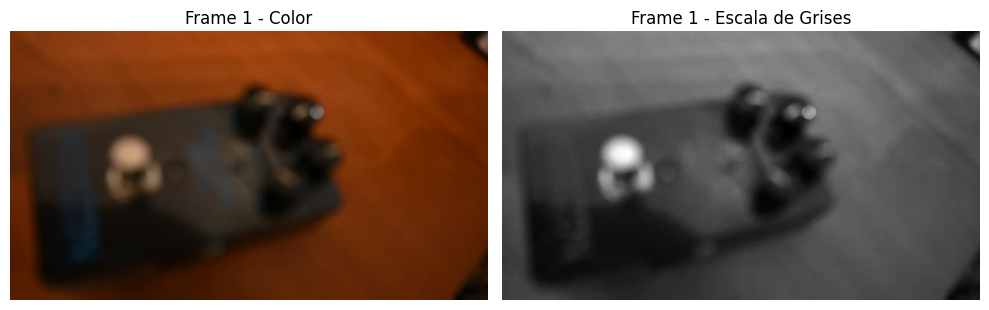

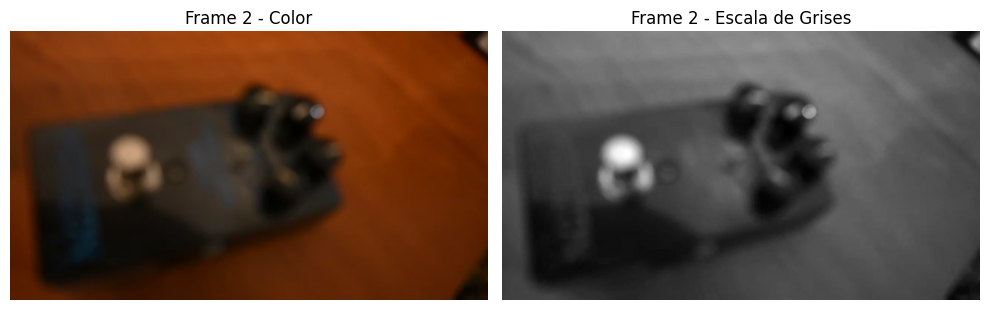

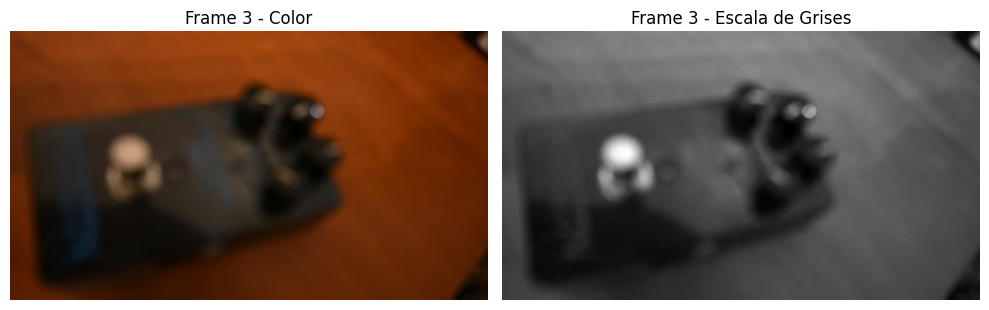

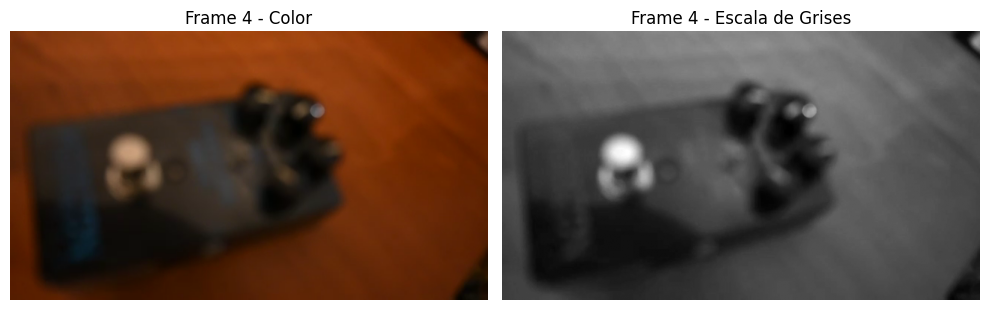

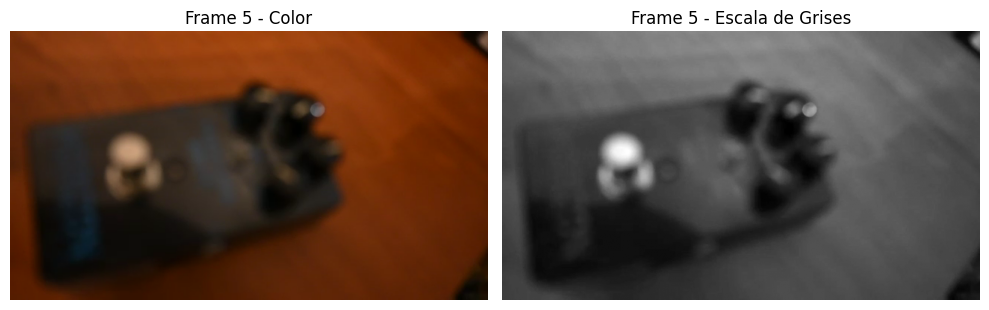

In [90]:
utils.show_n_frames(video_path, 5)

In [91]:
captura_video = cv.VideoCapture(video_path)

if captura_video.isOpened():
    # Obtiene dimensiones del video
    frame_width = int(captura_video.get(cv.CAP_PROP_FRAME_WIDTH))
    frame_height = int(captura_video.get(cv.CAP_PROP_FRAME_HEIGHT))
    new_width = frame_width // 2
    new_height = frame_height // 2
    
    # Obtiene la tasa de cuadros por segundo
    fps = int(captura_video.get(cv.CAP_PROP_FPS))
    delay = int(600 / fps)
    
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
    
        # Redimensionar frame a la mitad
        frame_resized = cv.resize(frame, (new_width, new_height))
    
        # Mostrar frame
        cv.imshow('Video', frame_resized)
    
        # Salir con la tecla 'q'
        if cv.waitKey(delay) & 0xFF == ord('q'):
            break
    
    # Liberar recursos
    captura_video.release()
    cv.destroyAllWindows()
    cv.waitKey(1)

## 1. Medición sobre todo el frame.

CSV exportado a: material/fm/frecuencia_fm.csv
Gráfico guardado como: material/fm/frecuencia_fm.png


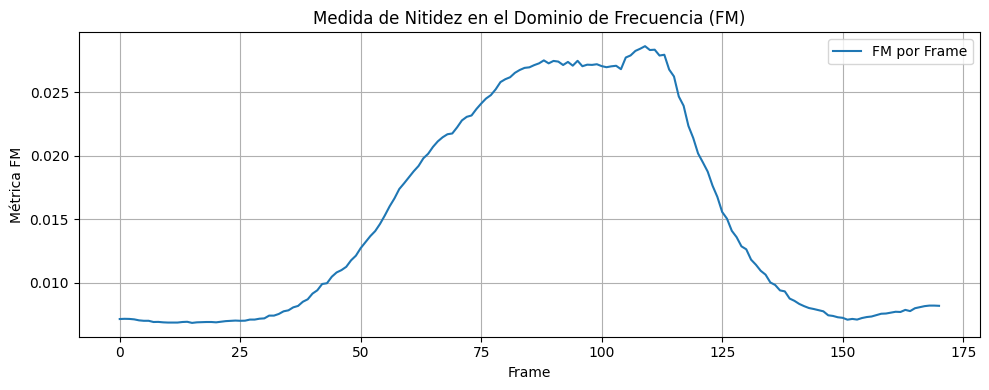

Mostrando los 3 frames con menor FM:


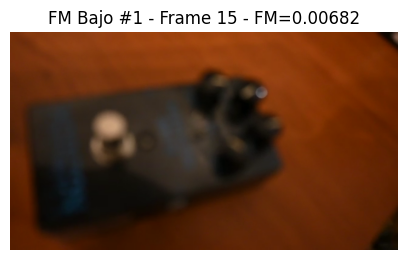

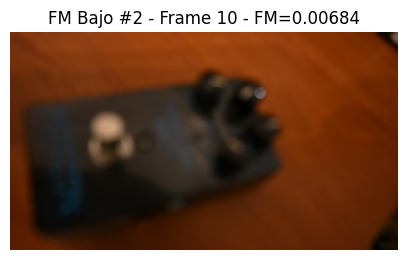

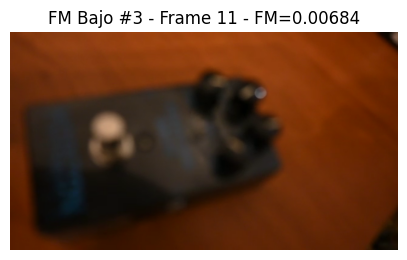

Mostrando los 3 frames con mayor FM:


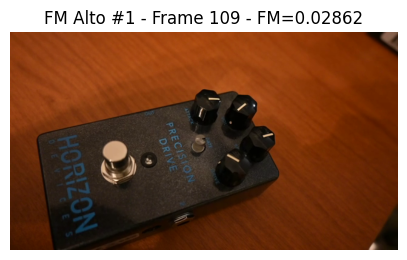

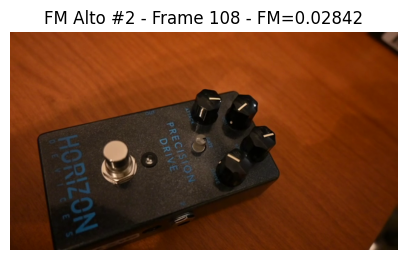

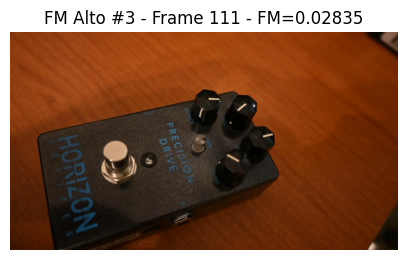

In [92]:
fm_values, frames_processed = utils.process_video(video_path)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM)")
    utils.show_extreme_frames(fm_values, frames_processed, n=3)

## 2. Medición sobre una ROI ubicada en el centro del frame.

CSV exportado a: material/fm/fm_roi_0.05.csv
Gráfico guardado como: material/fm/fm_roi_0.05.png


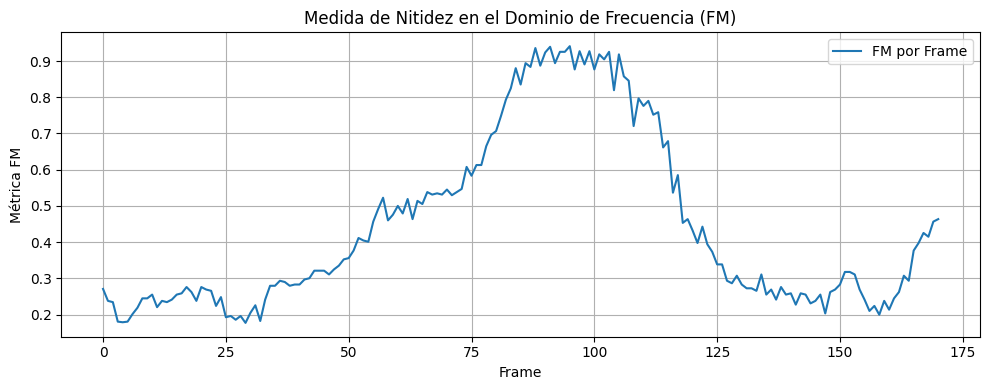

Mostrando los 1 frames con menor FM:


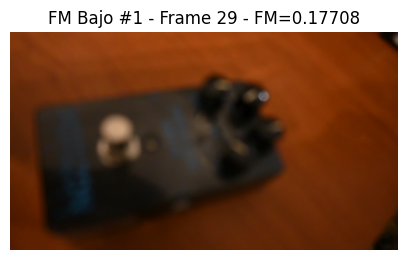

Mostrando los 1 frames con mayor FM:


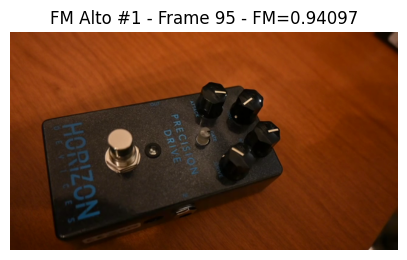

In [107]:
fm_values, frames_processed = utils.process_video_with_roi(video_path, 0.05)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, roi=0.05, plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM) ROI=0.05")
    utils.show_extreme_frames(fm_values, frames_processed, n=1)

CSV exportado a: material/fm/fm_roi_0.10.csv
Gráfico guardado como: material/fm/fm_roi_0.10.png


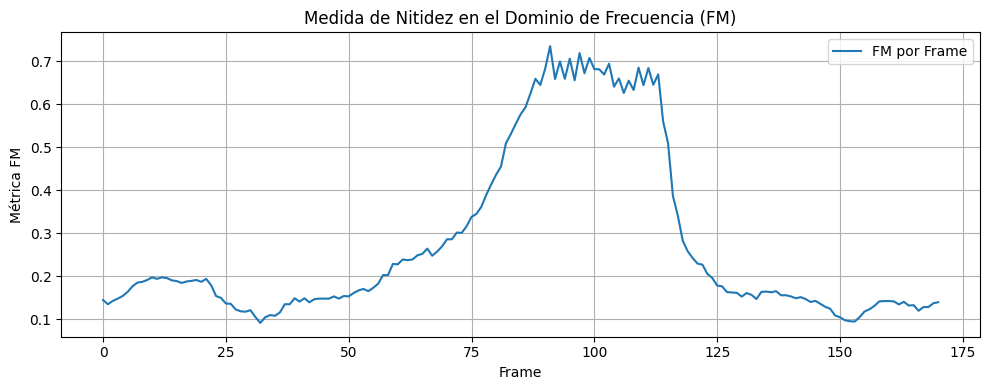

Mostrando los 1 frames con menor FM:


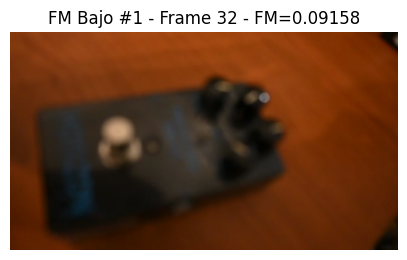

Mostrando los 1 frames con mayor FM:


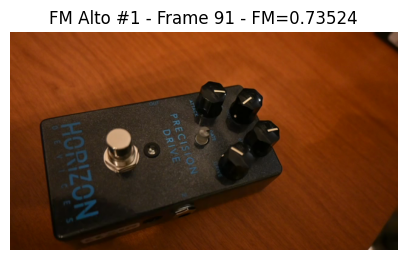

In [ ]:
fm_values, frames_processed = utils.process_video_with_roi(video_path, 0.1)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM) ROI=0.1", roi=0.1)
    utils.show_extreme_frames(fm_values, frames_processed, n=1)

In [116]:
roi_values = [0.05, 0.1, 1.0]
repeticiones = 5  # Número de veces que se repite cada medición
tiempos_promedio = {}

for roi_pct in roi_values:
    tiempos = []
    for _ in range(repeticiones):
        start_time = time.time()
        _ = utils.process_video_with_roi(video_path, roi_pct)
        tiempo = time.time() - start_time
        tiempos.append(tiempo)
    promedio = np.mean(tiempos)
    tiempos_promedio[roi_pct] = promedio

# Mostrar resultados
for roi, t_prom in tiempos_promedio.items():
    print(f"ROI {roi:.2f} → Tiempo promedio: {t_prom:.4f} segundos en {repeticiones} ejecuciones")

ROI 0.05 → Tiempo promedio: 0.1356 segundos en 5 ejecuciones
ROI 0.10 → Tiempo promedio: 0.1435 segundos en 5 ejecuciones
ROI 1.00 → Tiempo promedio: 2.0312 segundos en 5 ejecuciones


## 3. Medición sobre una matriz de enfoque 

**Procedimiento**

1. **Segmentación** Divido cada frame en una grilla *N × M* (p. ej., 3×3, 5×5, 7×5).  
2. **Cálculo en cada bloque**  


    - Transformada de Fourier:  
        $$F = \mathcal{F}\{I\}$$  
    - Centración:  
        $$F_c = \operatorname{fftshift}(F)$$  
    - Módulo espectral:  
        $$A_F = |F_c|$$  
    - Umbral fijo:  
        $$\mathrm{thres} = \frac{\max(A_F)}{1000}$$  
    - Conteo de altas frecuencias:  
        $$
        TH = \bigl|\{\,p \in A_F \;\big|\; p > \mathrm{thres}\}\bigr|
        $$
 
    - Métrica final:  
        $$FM = \frac{TH}{H \times W}$$  



3. **Visualización** Represento los valores en un mapa de calor:  
   * **Tonos claros → FM alta → zona nítida**  
   * **Tonos oscuros → FM baja → zona desenfocada o con poco detalle**



---
| Resolución | Caso de uso recomendado |
|------------|-------------------------|
| **3×3 / 5×5** | Diagnóstico rápido: identifica el cuadrante enfocado sin ruido excesivo. |
| **≥ 7×5** | Localización precisa dentro de la zona nítida; tolera algo más de variabilidad numérica. |

---

In [125]:
grid_configs = [
    (3, 3),
    (7, 5),
    (5, 5),
]

In [138]:
import importlib
import util as utils
importlib.reload(utils)

<module 'util' from 'c:\\Users\\Iñaki\\Desktop\\Master inteligencia artificial\\vpc1_19co2025\\tp2\\util.py'>

CSV exportado a: material\fm\grid_3x3/fm.csv
Gráfico guardado como: material\fm\grid_3x3/fm.png


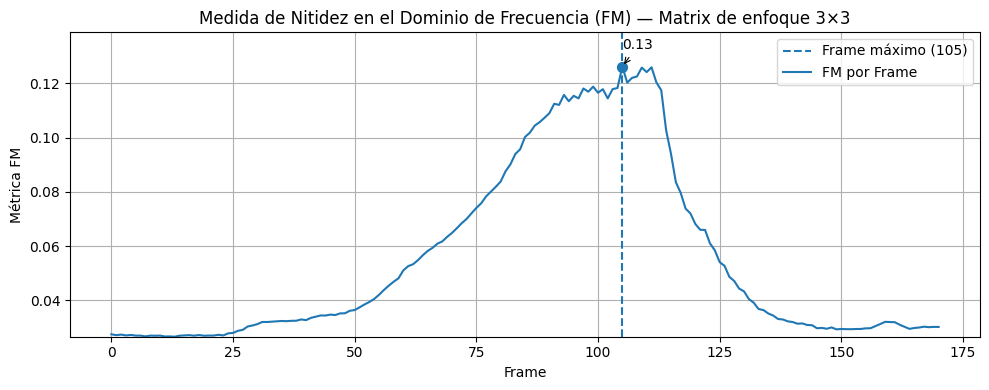

Mostrando los 1 frames con menor FM:


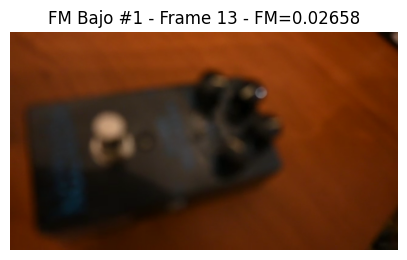

Mostrando los 1 frames con mayor FM:


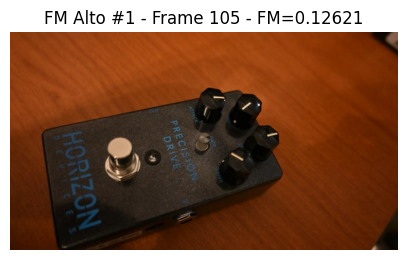

CSV exportado a: material\fm\grid_7x5/fm.csv
Gráfico guardado como: material\fm\grid_7x5/fm.png


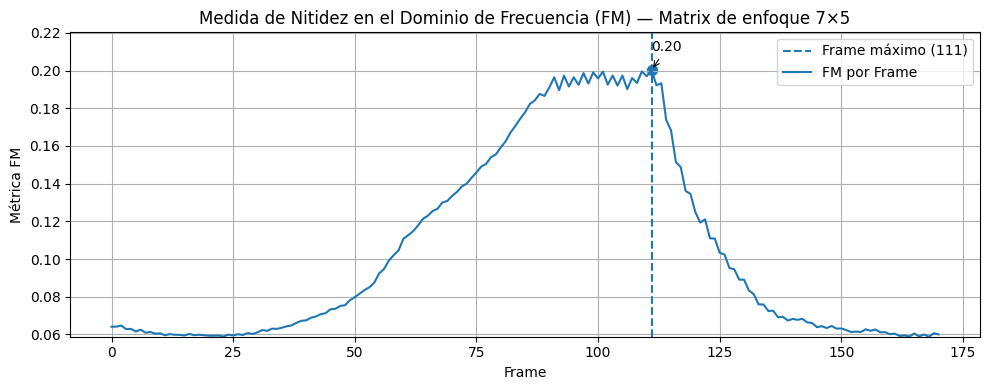

Mostrando los 1 frames con menor FM:


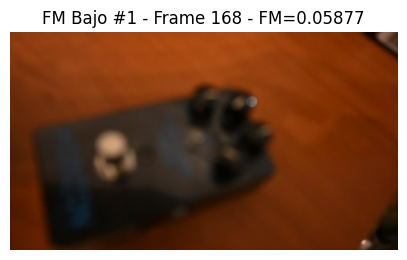

Mostrando los 1 frames con mayor FM:


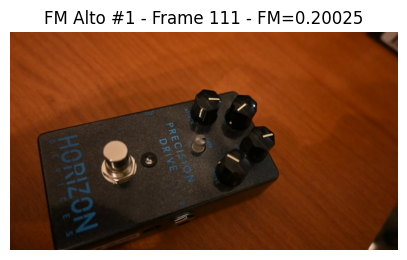

CSV exportado a: material\fm\grid_5x5/fm.csv
Gráfico guardado como: material\fm\grid_5x5/fm.png


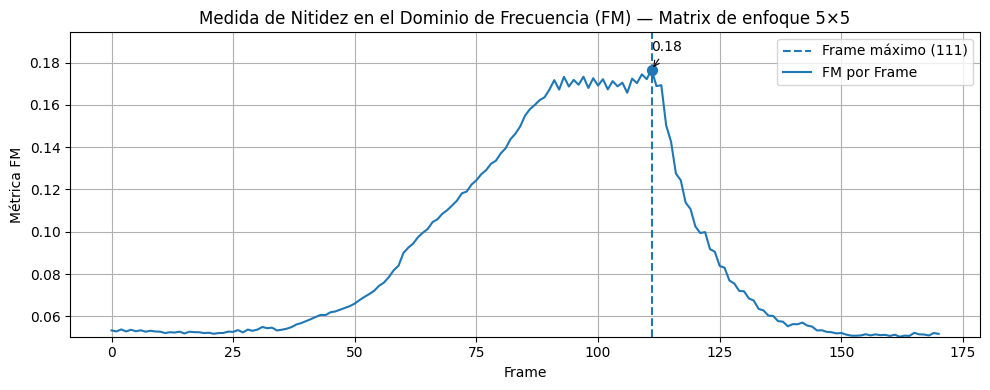

Mostrando los 1 frames con menor FM:


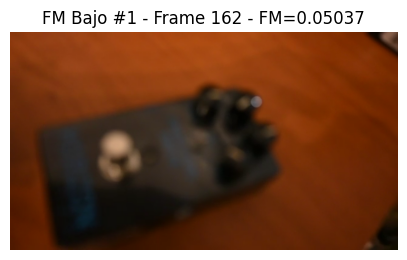

Mostrando los 1 frames con mayor FM:


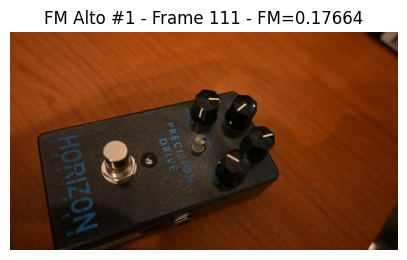

In [139]:
for rows, cols in grid_configs:
    suffix = f"grid_{rows}x{cols}"
    out_dir = Path(output_analysis_path) / suffix
    out_dir.mkdir(parents=True, exist_ok=True)

    fm_grid, frames_grid = utils.process_video_grid(
        video_path,
        rows,
        cols,
        threshold_factor=1000,
        agg="mean"
    )
    utils.export_and_plot_fm(
        fm_grid,
        str(out_dir),
        roi=None,
        grid=(rows, cols), 
        plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM)"
    )

    utils.show_extreme_frames(fm_grid, frames_grid, n=1)


In [126]:
n_runs = 5

avg_times = utils.benchmark_grid_configs(video_path, grid_configs, n_runs)

for (rows, cols), t in avg_times.items():
    print(f"Grid {rows}×{cols}: {t:.3f} s en promedio sobre {n_runs} corridas")

Grid 3×3: 2.409 s en promedio sobre 5 corridas
Grid 7×5: 1.740 s en promedio sobre 5 corridas
Grid 5×5: 1.223 s en promedio sobre 5 corridas


### Analisis del primer frame

In [ ]:
cap = cv.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

utils.show_n_frames(video_path, 1)

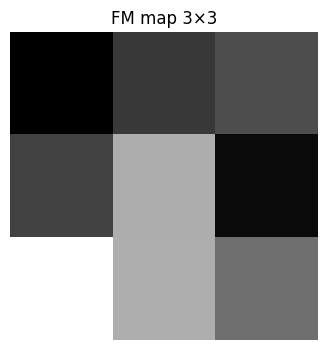

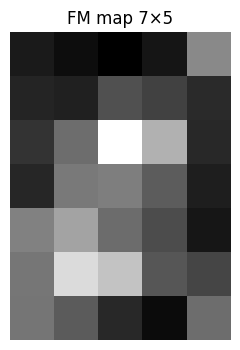

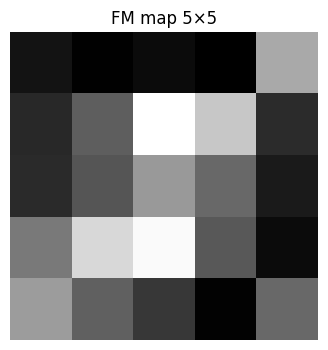

In [ ]:
for rows, cols in grid_configs:
    fm_map = utils.measure_grid_focus_map(frame_gray, rows, cols)
    utils.show_image(fm_map, title=f"FM map {rows}×{cols}")

In [ ]:
fm_map = utils.measure_grid_focus_map(frame_gray, 3, 3)
print(fm_map)

[[0.01463224 0.02183099 0.02433801]
 [0.0228482  0.0362676  0.01600467]
 [0.04663537 0.03638498 0.02838785]]


### Comparacion con frame 109

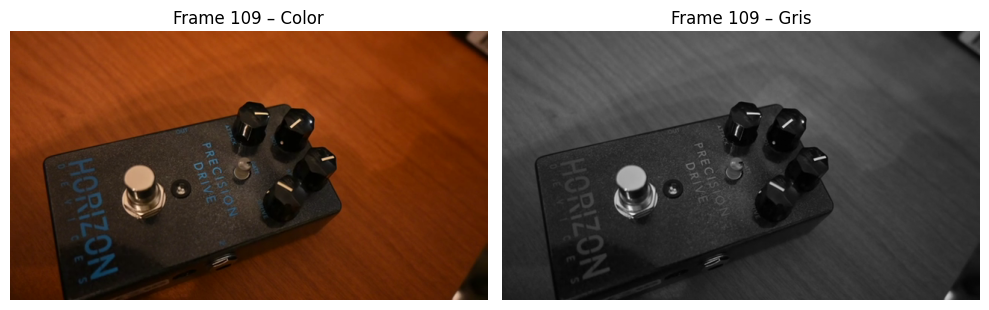

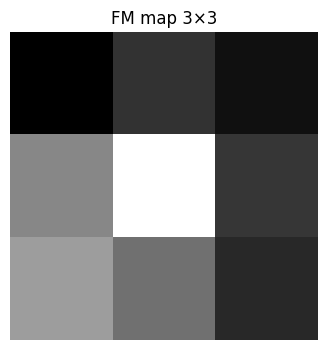

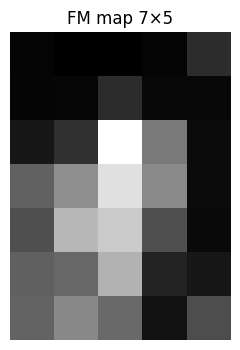

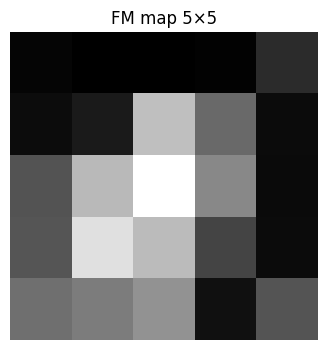

In [108]:
frame_109_gray = utils.show_frame(video_path, 109, to_gray=True)

for rows, cols in grid_configs:
    fm_map = utils.measure_grid_focus_map(frame_109_gray, rows, cols)
    utils.show_image(fm_map, title=f"FM map {rows}×{cols}")

In [109]:
fm_map = utils.measure_grid_focus_map(frame_109_gray, 3, 3)
print(fm_map)

[[0.01271518 0.07496088 0.03309969]
 [0.18043819 0.32871675 0.08049066]
 [0.20672926 0.15105633 0.06417446]]


In [110]:
import importlib 
import util as utils 
importlib.reload(utils)

<module 'util' from 'c:\\Users\\Iñaki\\Desktop\\Master inteligencia artificial\\vpc1_19co2025\\tp2\\util.py'>